# Понижение размерности

In [1]:
import pandas as pd

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

In [3]:
def test(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    knn = KNeighborsClassifier(n_neighbors=3, metric='minkowski', p=2)
    knn.fit(X_train, y_train)
    y_bin_knn_pred = knn.predict(X_test)
    print(classification_report(y_test, y_bin_knn_pred))

In [4]:
data = pd.read_csv("../data/processed_smoke_detector.csv")
data.head(5)

,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],NC2.5,Fire Alarm,IsItDay?,Weekday_0,Weekday_1,Weekday_2
0,27.041,49.80,19.0,400.0,13059.0,19951,939.777,0.011,0,0,0,0,1
1,26.987,54.26,1.0,400.0,13078.0,19975,939.765,0.011,0,0,0,0,1
2,26.985,53.66,10.0,400.0,13068.0,19955,939.768,0.011,0,0,0,0,1
3,26.983,53.07,10.0,400.0,13069.0,19963,939.775,0.013,0,0,0,0,1
4,26.982,52.57,13.0,400.0,13072.0,19958,939.770,0.013,0,0,0,0,1


In [6]:
X = data.drop(labels=["Fire Alarm"], axis=1)
y = data["Fire Alarm"]
print(X.shape, y.shape)

(41247, 12) (41247,)


In [7]:
test(X, y)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1810
           1       1.00      1.00      1.00      6440

    accuracy                           1.00      8250
   macro avg       1.00      1.00      1.00      8250
weighted avg       1.00      1.00      1.00      8250



In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X.head()

,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],NC2.5,IsItDay?,Weekday_0,Weekday_1,Weekday_2
0,0.897490,-0.077616,-1.448663,-0.526116,0.751367,0.472027,1.427404,-2.568140,-1.1446,-0.264239,-0.263766,0.264239
1,0.892909,1.197752,-1.483350,-0.526116,0.883753,0.527991,1.409056,-2.568140,-1.1446,-0.264239,-0.263766,0.264239
2,0.892740,1.026178,-1.466007,-0.526116,0.814076,0.481355,1.413643,-2.568140,-1.1446,-0.264239,-0.263766,0.264239
3,0.892570,0.857463,-1.466007,-0.526116,0.821044,0.500009,1.424346,-2.396949,-1.1446,-0.264239,-0.263766,0.264239
4,0.892485,0.714484,-1.460226,-0.526116,0.841947,0.488350,1.416701,-2.396949,-1.1446,-0.264239,-0.263766,0.264239


In [10]:
test(X, y)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1810
           1       1.00      1.00      1.00      6440

    accuracy                           1.00      8250
   macro avg       1.00      1.00      1.00      8250
weighted avg       1.00      1.00      1.00      8250



## 1. Отбор признаков

### Variance Threshold

In [19]:
from sklearn.feature_selection import VarianceThreshold

In [20]:
vt = VarianceThreshold(1)
X_vt = vt.fit_transform(X)
X_vt.shape

(41247, 5)

In [21]:
X_vt = pd.DataFrame(X_vt, columns=vt.get_feature_names_out())
X_vt.head()

,Temperature[C],Raw H2,Weekday_0,Weekday_1,Weekday_2
0,0.897490,0.751367,-0.264239,-0.263766,0.264239
1,0.892909,0.883753,-0.264239,-0.263766,0.264239
2,0.892740,0.814076,-0.264239,-0.263766,0.264239
3,0.892570,0.821044,-0.264239,-0.263766,0.264239
4,0.892485,0.841947,-0.264239,-0.263766,0.264239


In [22]:
test(X_vt, y)

              precision    recall  f1-score   support

           0       0.95      0.94      0.95      1810
           1       0.98      0.99      0.98      6440

    accuracy                           0.98      8250
   macro avg       0.97      0.96      0.97      8250
weighted avg       0.98      0.98      0.98      8250



### SelectKBest

In [23]:
from sklearn.feature_selection import SelectKBest

In [24]:
skb = SelectKBest(k=2)
X_skb = skb.fit_transform(X, y)
X_skb = pd.DataFrame(X_skb, columns=skb.get_feature_names_out())
X_skb.head()

,TVOC[ppb],Raw Ethanol
0,-1.448663,0.472027
1,-1.483350,0.527991
2,-1.466007,0.481355
3,-1.466007,0.500009
4,-1.460226,0.488350


In [25]:
test(X_skb, y)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1810
           1       1.00      1.00      1.00      6440

    accuracy                           1.00      8250
   macro avg       1.00      1.00      1.00      8250
weighted avg       1.00      1.00      1.00      8250



### RFE (рекурсивный отбор признаков)

In [26]:
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier

In [27]:
tree = DecisionTreeClassifier().fit(X, y)

In [28]:
rfe = RFE(estimator=tree, n_features_to_select=2, step=1).fit(X, y)
X_rfe = pd.DataFrame(rfe.transform(X), columns=rfe.get_feature_names_out())
X_rfe

,TVOC[ppb],Raw H2
0,-1.448663,0.751367
1,-1.483350,0.883753
2,-1.466007,0.814076
3,-1.466007,0.821044
4,-1.460226,0.841947
...,...,...
41242,-1.284867,-0.342560
41243,-1.319553,-0.265915
41244,-1.315699,-0.335592
41245,-1.327261,-0.231077


In [29]:
test(X_rfe, y)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1810
           1       1.00      1.00      1.00      6440

    accuracy                           1.00      8250
   macro avg       1.00      1.00      1.00      8250
weighted avg       1.00      1.00      1.00      8250



## 2. Выделение признаков

### PCA 

In [30]:
from sklearn.decomposition import PCA

In [31]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X, y)
X_pca.shape

(41247, 2)

In [32]:
import matplotlib.pyplot as plt

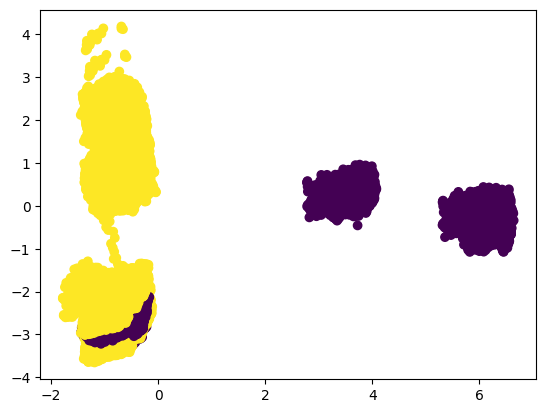

In [33]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=y)

In [34]:
sum(pca.explained_variance_ratio_)

0.5465739751788792

In [35]:
test(X_pca, y)

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1810
           1       0.97      0.96      0.96      6440

    accuracy                           0.94      8250
   macro avg       0.92      0.92      0.92      8250
weighted avg       0.94      0.94      0.94      8250



In [36]:
pca_2 = PCA(n_components=3)
X_pca_2 = pca_2.fit_transform(X, y)

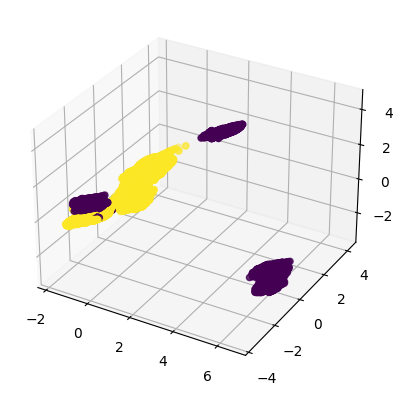

In [37]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X_pca_2[:,0], X_pca_2[:,1], X_pca_2[:,2], c=y)

In [38]:
test(X_pca_2, y)

              precision    recall  f1-score   support

           0       0.96      0.95      0.96      1810
           1       0.99      0.99      0.99      6440

    accuracy                           0.98      8250
   macro avg       0.97      0.97      0.97      8250
weighted avg       0.98      0.98      0.98      8250



### Kernel PCA

In [53]:
from sklearn.decomposition import KernelPCA

In [54]:
kernels = [
    {'name': 'poly', 'params': {'gamma': 3, 'degree': 3, 'coef0': 1}},
    {'name': 'rbf', 'params': {'gamma': 0.05}},
    {'name': 'sigmoid', 'params': {'gamma': 0.1, 'coef0': 1}}
]

In [55]:
sample = data.sample(frac=0.25, random_state=42)
X = sample.drop(labels=["Fire Alarm"], axis=1)
y = sample["Fire Alarm"]


--- Kernel: POLY ---


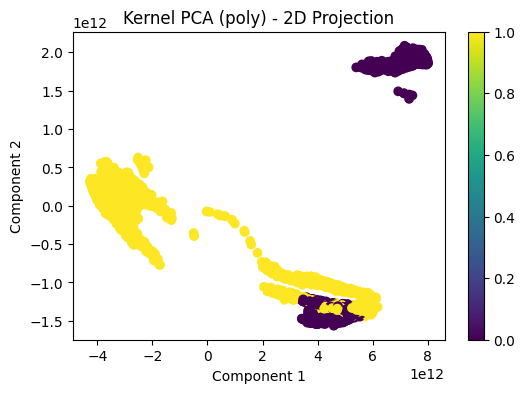

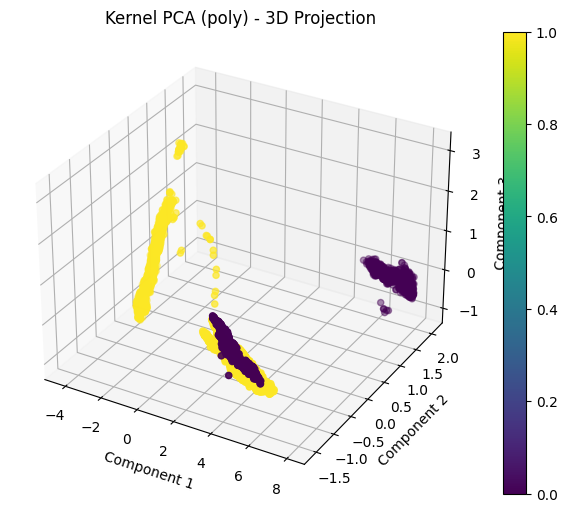

Результаты для 2D:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       463
           1       0.99      0.98      0.98      1600

    accuracy                           0.97      2063
   macro avg       0.96      0.97      0.96      2063
weighted avg       0.97      0.97      0.97      2063

Результаты для 3D:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       463
           1       1.00      1.00      1.00      1600

    accuracy                           1.00      2063
   macro avg       1.00      1.00      1.00      2063
weighted avg       1.00      1.00      1.00      2063


--- Kernel: RBF ---


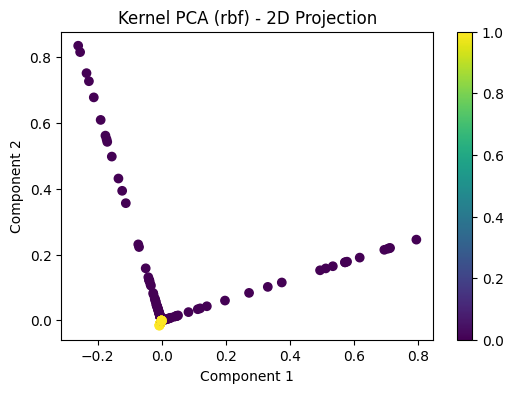

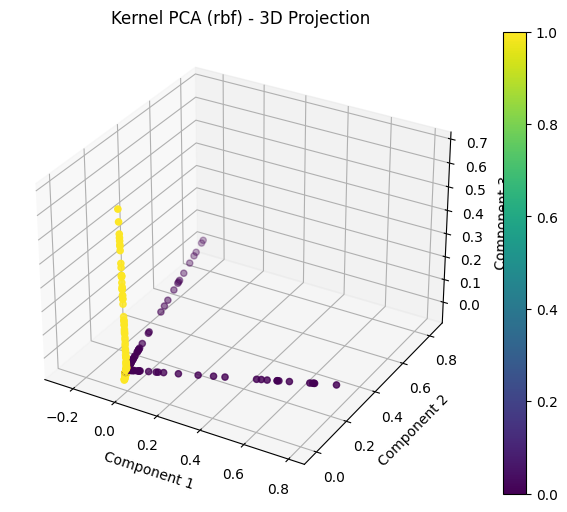

Результаты для 2D:
              precision    recall  f1-score   support

           0       0.30      0.19      0.23       463
           1       0.79      0.87      0.83      1600

    accuracy                           0.72      2063
   macro avg       0.54      0.53      0.53      2063
weighted avg       0.68      0.72      0.69      2063

Результаты для 3D:
              precision    recall  f1-score   support

           0       0.36      0.21      0.26       463
           1       0.80      0.89      0.84      1600

    accuracy                           0.74      2063
   macro avg       0.58      0.55      0.55      2063
weighted avg       0.70      0.74      0.71      2063


--- Kernel: SIGMOID ---


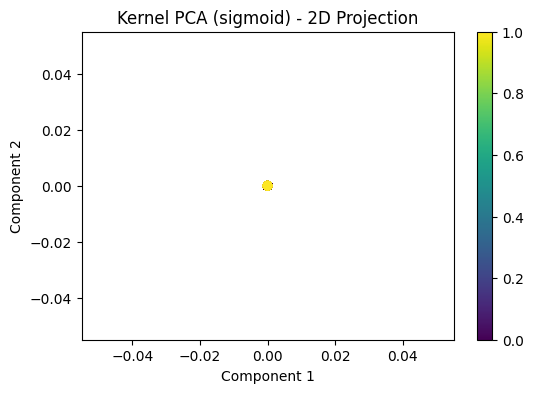

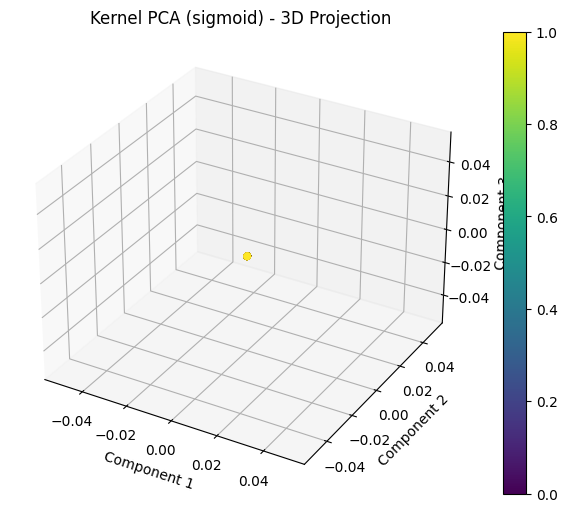

Результаты для 2D:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       463
           1       0.78      1.00      0.87      1600

    accuracy                           0.78      2063
   macro avg       0.39      0.50      0.44      2063
weighted avg       0.60      0.78      0.68      2063

Результаты для 3D:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       463
           1       0.78      1.00      0.87      1600

    accuracy                           0.78      2063
   macro avg       0.39      0.50      0.44      2063
weighted avg       0.60      0.78      0.68      2063



d:\Programming\ML-labs\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Programming\ML-labs\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Programming\ML-labs\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Programming\ML-labs\.venv

In [ ]:
for kernel_config in kernels:
    kernel_name = kernel_config['name']
    params = kernel_config['params']
    
    print(f"\n--- Kernel: {kernel_name.upper()} ---")
    
    kpca_2d = KernelPCA(n_components=2, kernel=kernel_name, **params)
    X_kpca_2d = kpca_2d.fit_transform(X)
    
    plt.figure(figsize=(6, 4))
    plt.scatter(X_kpca_2d[:, 0], X_kpca_2d[:, 1], c=y, cmap='viridis')
    plt.title(f'Kernel PCA ({kernel_name}) - 2D Projection')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.colorbar()
    plt.show()
    
    kpca_3d = KernelPCA(n_components=3, kernel=kernel_name, **params)
    X_kpca_3d = kpca_3d.fit_transform(X)
    
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X_kpca_3d[:, 0], X_kpca_3d[:, 1], X_kpca_3d[:, 2], c=y, cmap='viridis')
    plt.colorbar(scatter)
    ax.set_title(f'Kernel PCA ({kernel_name}) - 3D Projection')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_zlabel('Component 3')
    plt.show()
    
    print("Результаты для 2D:")
    test(X_kpca_2d, y)
    
    print("Результаты для 3D:")
    test(X_kpca_3d, y)

## 2.2 Нелиненые методы выделения призанков

In [43]:
sample = data.sample(frac=0.25, random_state=42)
X = sample.drop(labels=["Fire Alarm"], axis=1)
y = sample["Fire Alarm"]

### t-SNE

In [ ]:
# from sklearn.manifold import TSNE

In [ ]:
# tsne = TSNE(n_components=2, n_jobs=-1)

In [ ]:
# X_tsne = tsne.fit_transform(X)

In [ ]:
# plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y)

In [ ]:
# test(X_tsne, y)

### Isomap

In [49]:
from sklearn.manifold import Isomap

In [50]:
isomap = Isomap(n_components=2, n_jobs=-1)
X_isomap = isomap.fit_transform(X)

d:\Programming\ML-labs\.venv\Lib\site-packages\sklearn\manifold\_isomap.py:383: UserWarning: The number of connected components of the neighbors graph is 7 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
d:\Programming\ML-labs\.venv\Lib\site-packages\scipy\sparse\_index.py:100: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
d:\Programming\ML-labs\.venv\Lib\site-packages\scipy\sparse\_index.py:100: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
d:\Programming\ML-labs\.venv\Lib\site-packages\scipy\sparse\_index.py:100: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
d:\Programm

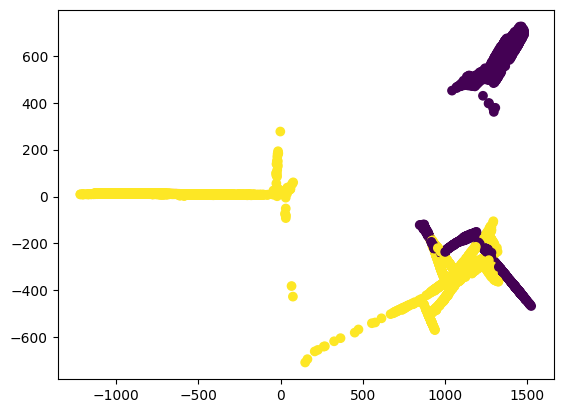

In [51]:
plt.scatter(X_isomap[:,0], X_isomap[:,1], c=y)

In [52]:
test(X_isomap, y)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       463
           1       1.00      1.00      1.00      1600

    accuracy                           1.00      2063
   macro avg       1.00      1.00      1.00      2063
weighted avg       1.00      1.00      1.00      2063



### UMAP

In [57]:
import umap

In [60]:
umap_configs = [
    {'n_neighbors': 15, 'min_dist': 0.1, 'metric': 'euclidean'},
    {'n_neighbors': 5, 'min_dist': 0.01, 'metric': 'euclidean'},
    {'n_neighbors': 50, 'min_dist': 0.5, 'metric': 'euclidean'},
    {'n_neighbors': 15, 'min_dist': 0.1, 'metric': 'cosine'}
]

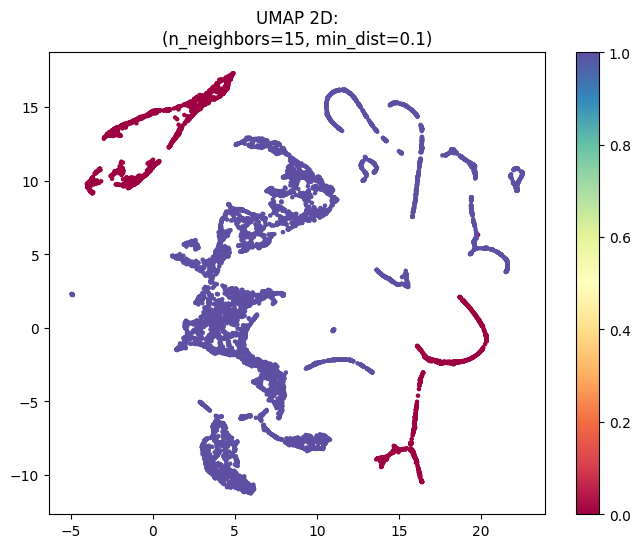

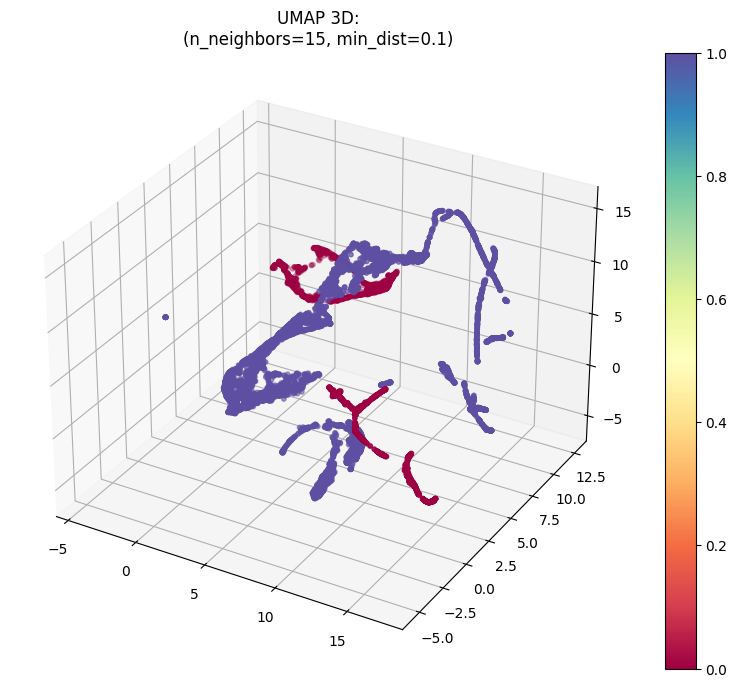

2D results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       463
           1       1.00      1.00      1.00      1600

    accuracy                           1.00      2063
   macro avg       1.00      1.00      1.00      2063
weighted avg       1.00      1.00      1.00      2063

3D results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       463
           1       1.00      1.00      1.00      1600

    accuracy                           1.00      2063
   macro avg       1.00      1.00      1.00      2063
weighted avg       1.00      1.00      1.00      2063



d:\Programming\ML-labs\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:301: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


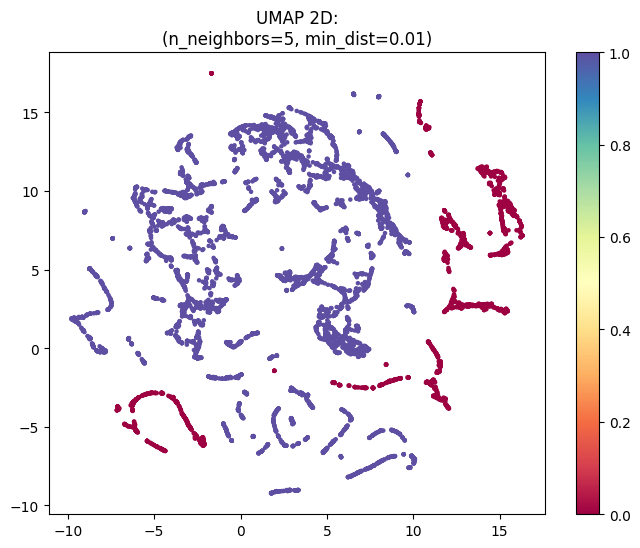

d:\Programming\ML-labs\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:301: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


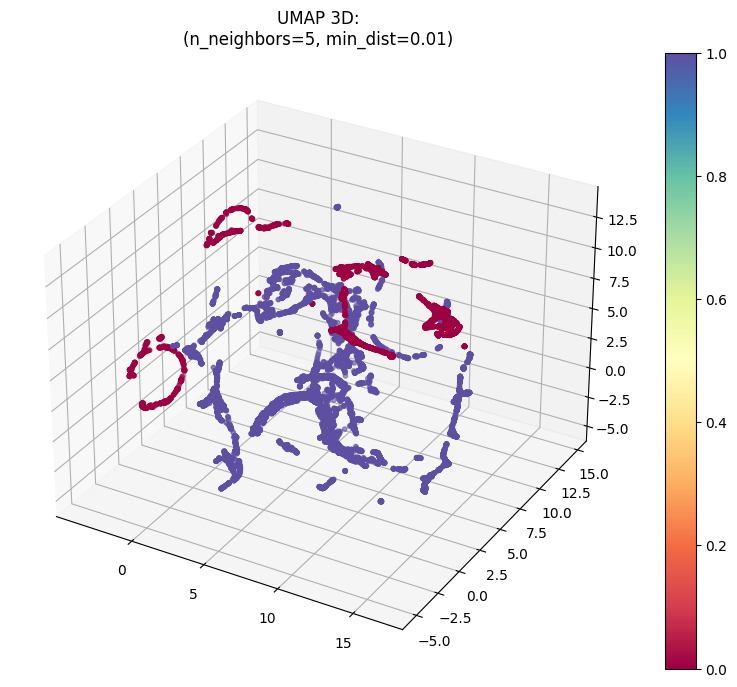

2D results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       463
           1       1.00      1.00      1.00      1600

    accuracy                           1.00      2063
   macro avg       1.00      1.00      1.00      2063
weighted avg       1.00      1.00      1.00      2063

3D results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       463
           1       1.00      1.00      1.00      1600

    accuracy                           1.00      2063
   macro avg       1.00      1.00      1.00      2063
weighted avg       1.00      1.00      1.00      2063



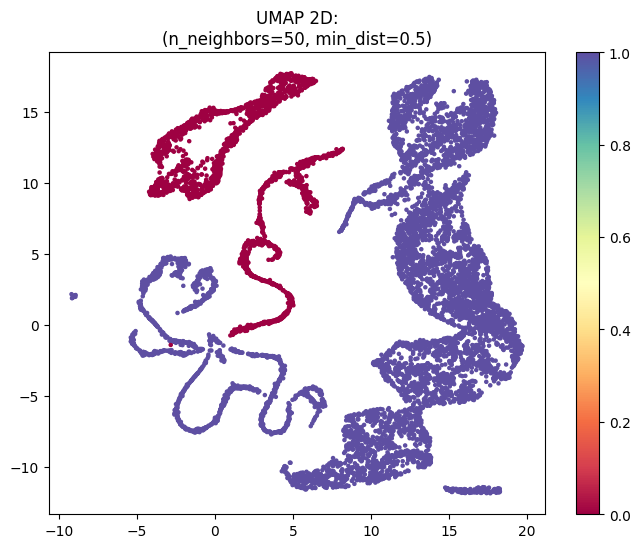

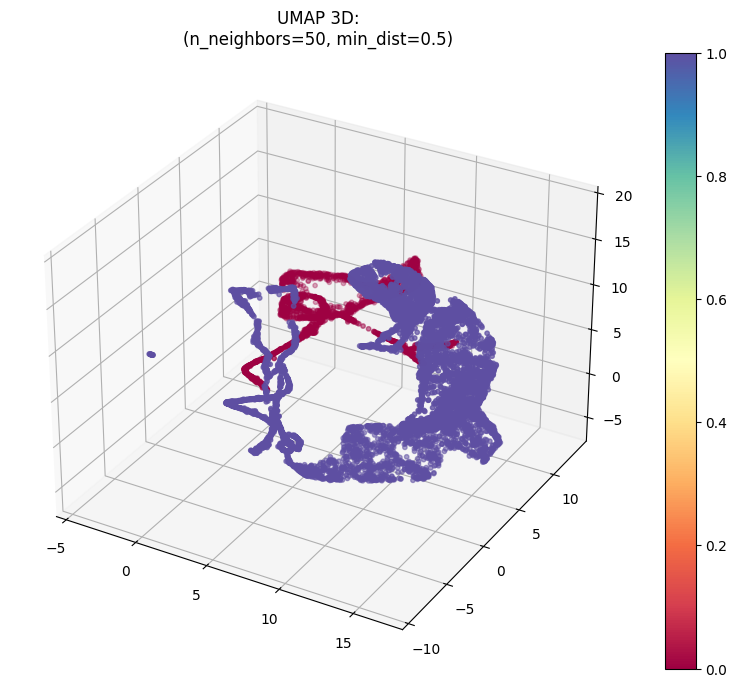

2D results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       463
           1       1.00      1.00      1.00      1600

    accuracy                           1.00      2063
   macro avg       1.00      1.00      1.00      2063
weighted avg       1.00      1.00      1.00      2063

3D results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       463
           1       1.00      1.00      1.00      1600

    accuracy                           1.00      2063
   macro avg       1.00      1.00      1.00      2063
weighted avg       1.00      1.00      1.00      2063



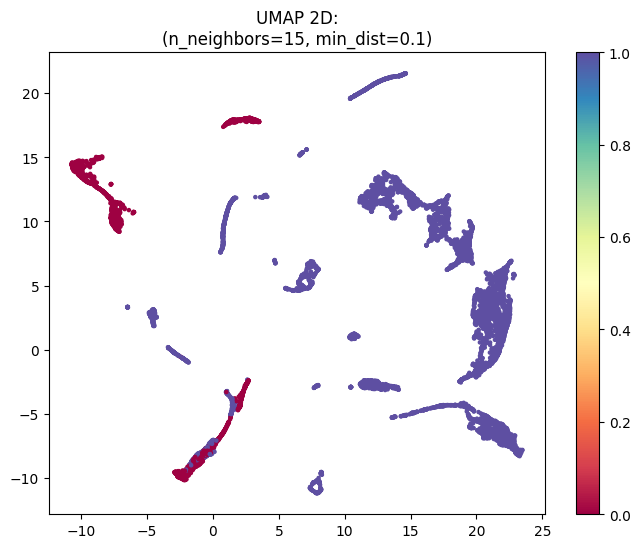

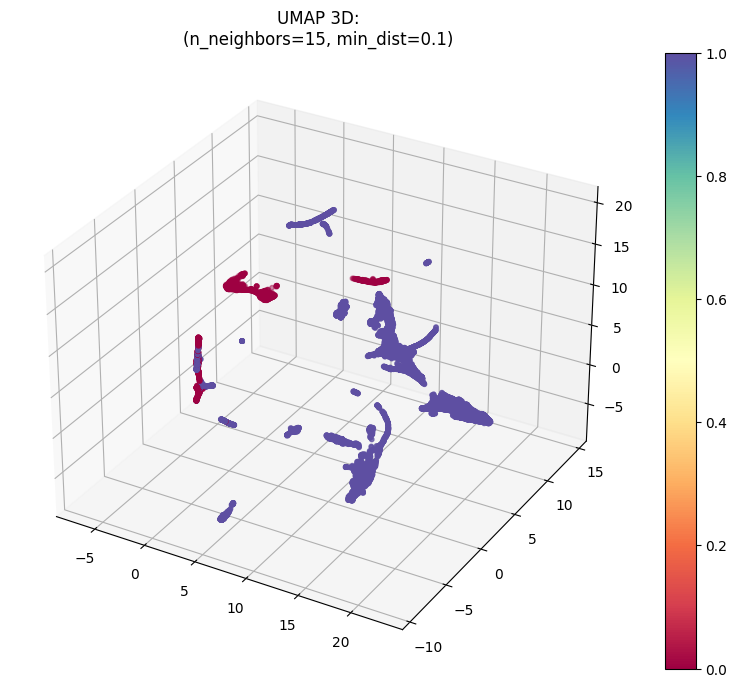

2D results:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       463
           1       0.99      0.99      0.99      1600

    accuracy                           0.99      2063
   macro avg       0.98      0.98      0.98      2063
weighted avg       0.99      0.99      0.99      2063

3D results:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       463
           1       0.99      0.99      0.99      1600

    accuracy                           0.99      2063
   macro avg       0.98      0.98      0.98      2063
weighted avg       0.99      0.99      0.99      2063



In [62]:
for config in umap_configs:

    reducer_2d = umap.UMAP(n_components=2, **config)
    embedding_2d = reducer_2d.fit_transform(X)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=y, cmap='Spectral', s=5)
    plt.title(f"UMAP 2D:\n(n_neighbors={config['n_neighbors']}, min_dist={config['min_dist']})")
    plt.colorbar()
    plt.show()
    
    reducer_3d = umap.UMAP(n_components=3, **config)
    embedding_3d = reducer_3d.fit_transform(X)
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(embedding_3d[:, 0], embedding_3d[:, 1], embedding_3d[:, 2], 
                   c=y, cmap='Spectral', s=10)
    plt.colorbar(sc)
    ax.set_title(f"UMAP 3D:\n(n_neighbors={config['n_neighbors']}, min_dist={config['min_dist']})")
    plt.show()
    
    print("2D results:")
    test(embedding_2d, y)
    
    print("3D results:")
    test(embedding_3d, y)